# Sales Data Integrity Audit

## 📌 Objective
Audit the statistical health of the sales model inputs. Checking for multicollinearity and correlation leakage.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

%matplotlib inline
sns.set_theme(style="whitegrid")

df = pd.read_parquet("../data/model/model_sales.parquet")

# Check for numeric columns only
numeric_df = df.select_dtypes(include=[np.number])
print(f"🔹 Numeric Features available: {numeric_df.columns.tolist()}")

🔹 Numeric Features available: ['area', 'bedrooms', 'bathrooms', 'balcony', 'ready_to_move', 'is_luxury', 'is_gated_community', 'is_vastu_compliant', 'has_pool', 'has_gym', 'has_lift', 'is_individual', 'price_per_sqft', 'latitude', 'longitude', 'h3_median_price', 'h3_listings_count', 'local_zscore', 'geo_confidence']


## 1. Multicollinearity Audit (VIF)
Ensuring Area and Bathroom counts are not perfectly colinear.

In [ ]:
vif_cols = ['area', 'bedrooms', 'bathrooms']
X = df[vif_cols].dropna()
vif_data = pd.DataFrame()
vif_data["feature"] = vif_cols
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(vif_cols))]
print(vif_data)

     feature       VIF
0       area  2.182347
1   bedrooms       inf
2  bathrooms       inf


d:\ANACONDA py\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


## 2. Correlation Map

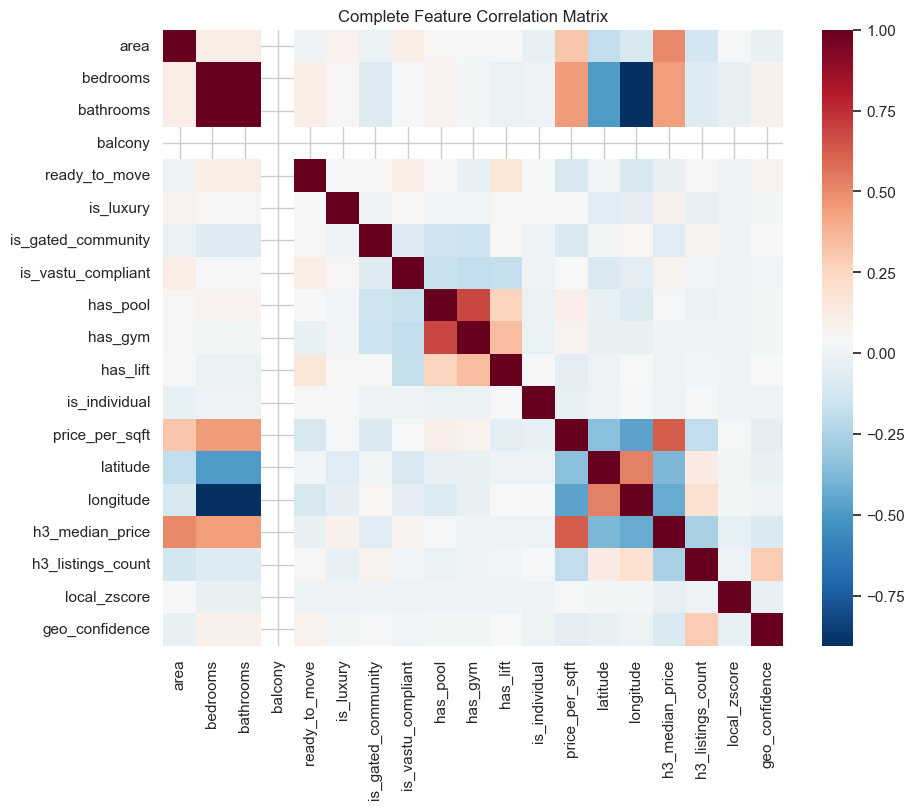

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=False, cmap='RdBu_r')
plt.title("Complete Feature Correlation Matrix")
plt.show()